In [ ]:
from pathlib import Path
import os

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from llm_equilibrium_core import Dataset

jax.config.update("jax_enable_x64", True)

# Load JSONs from raw into output
input_dir = "raw"
output_dir = "output"

output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

for file in os.listdir(input_dir):
    dataset = Dataset.from_json(f"{input_dir}/{file}")
    dataset.to_npz(output_dir / f"{file.split('.')[0]}.npz")

### Viz

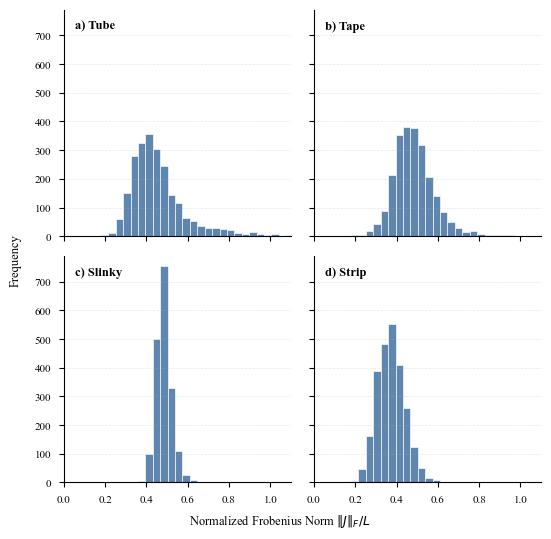

In [ ]:
import string


def visualize_sensitivity_batch_neurips(file_list, bins=60):
    """
    Creates a 5.5x5.5 2x2 grid with subpanel labeling (a, b, c, d)
    and custom material name mapping.
    """
    # 1. Publication Style Setup
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Times New Roman"],
            "font.size": 9,
            "axes.labelsize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "axes.titlesize": 10,
            "figure.titlesize": 11,
            "text.usetex": False,  # Switch to True if your system has LaTeX
        }
    )

    # Custom mapping dictionary
    name_map = {
        "slinky": "Slinky",
        "measuringtape": "Tape",
        "brazier": "Tube",
        "strip": "Strip",
    }

    fig, axes = plt.subplots(2, 2, figsize=(5.5, 5.5), sharex=True, sharey=True)
    axes = axes.flatten()

    all_norms = []
    global_max = 0

    # Data Loading pass
    for file in file_list:
        data = jnp.load(file)
        S = data["S"]
        norms = jnp.linalg.norm(S, ord="fro", axis=(1, 2)) / data["length"]
        all_norms.append(norms)
        global_max = max(global_max, float(jnp.max(norms)))

    # 3. Plotting loop
    for i, file in enumerate(file_list):
        ax = axes[i]

        # Plotting
        ax.hist(
            all_norms[i],
            bins=bins,
            range=(0, global_max),
            color="#4e79a7",
            edgecolor="white",
            linewidth=0.5,
            alpha=0.9,
        )

        # Name Mapping logic
        raw_name = file.split("/")[-1].split("_2d_")[0].replace("DLO_", "").lower()
        display_name = name_map.get(raw_name, raw_name.title())

        # Subpanel Labeling (a, b, c, d)
        # Positioned slightly inside the top left
        ax.text(
            0.05,
            0.95,
            f"{string.ascii_lowercase[i]}) {display_name}",
            transform=ax.transAxes,
            fontsize=9,
            fontweight="bold",
            va="top",
        )

        # ax.set_title(display_name, fontweight="bold", pad=8)

        # Clean aesthetics
        ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Optimization: Cut the dead space on the right (adjust 1.1 if needed)
        ax.set_xlim(0, 1.1)

    # 4. Global Labels
    fig.text(0.5, 0.02, r"Normalized Frobenius Norm $\|J\|_F/L$", ha="center")
    fig.text(0.01, 0.5, "Frequency", va="center", rotation="vertical")

    # Adjust layout to prevent clipping of the global labels
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])

    plt.savefig("sensitivity_dist.pdf", dpi=300)
    plt.show()


# Example Usage:
my_files = [
    "data/DLO_brazier_2d_rect_2332pts_v1.npz",
    "data/DLO_measuringtape_2d_rect_2357pts_v1.npz",
    "data/DLO_slinky_2d_rect_1836pts_v1.npz",
    "data/DLO_strip_2d_rect_2512pts_v5.npz",
]

visualize_sensitivity_batch_neurips(my_files)